# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
# Load the libraries as required.
%load_ext dotenv
%dotenv 
import os
import sys
import dask.dataframe as dd
import pandas as pd
import numpy as np
from glob import glob

In [2]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv(r'C:\Users\Minal\DSI\production\05_src\data\fires\forestfires.csv', header = 0, names = columns))
fires_dt.head(10)


,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


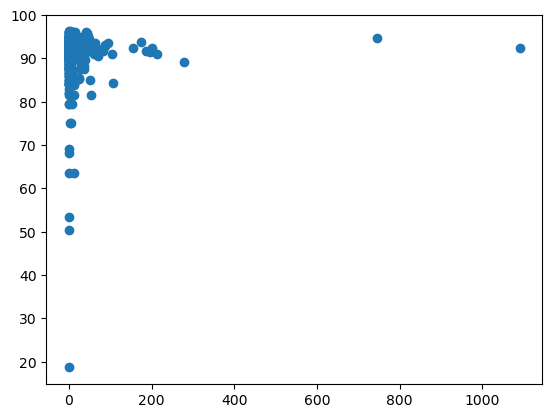

In [68]:
#visualizing relationship
import matplotlib.pyplot as plt
plt.plot(fires_dt['area'], fires_dt['ffmc'], 'o')
plt.show()

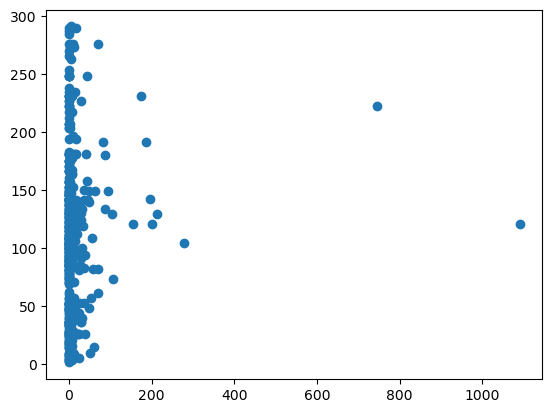

In [4]:
import matplotlib.pyplot as plt
plt.plot(fires_dt['area'], fires_dt['dmc'], 'o')
plt.show()

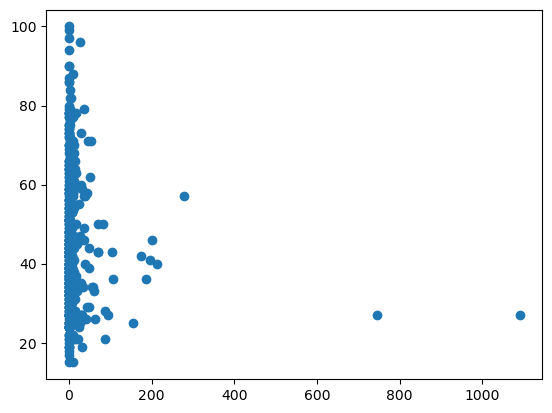

In [5]:
import matplotlib.pyplot as plt
plt.plot(fires_dt['area'], fires_dt['rh'], 'o')
plt.show()

# Get X and Y

Create the features data frame and target data.

In [69]:
#defining X - independent variables
X0 = fires_dt.iloc[:,:-1]
X0


,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0


In [70]:
#defining Y - response variable
Y0 = fires_dt.iloc[:,-1]
Y0

0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
       ...  
512     6.44
513    54.29
514    11.16
515     0.00
516     0.00
Name: area, Length: 517, dtype: float64

In [71]:
#data split in train and test set
from sklearn.model_selection import train_test_split
#splitting data in train and test
np.random.seed(1)

X0_train, X0_test, Y0_train, Y0_test = train_test_split(
    X0, Y0, train_size= 0.75, shuffle= True
)

X0_train

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain
300,6,5,jun,mon,90.4,93.3,298.1,7.5,20.7,25,4.9,0.0
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
355,4,4,sep,fri,92.1,99.0,745.3,9.6,20.8,35,4.9,0.0
80,1,2,aug,sun,91.4,142.4,601.4,10.6,19.5,39,6.3,0.0
46,5,6,sep,mon,90.9,126.5,686.5,7.0,14.7,70,3.6,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
129,2,5,oct,sun,92.6,46.5,691.8,8.8,15.4,35,0.9,0.0
144,2,5,aug,wed,95.5,99.9,513.3,13.2,23.8,32,5.4,0.0
72,5,4,mar,fri,91.7,33.3,77.5,9.0,15.6,25,6.3,0.0
235,8,6,aug,sun,91.4,142.4,601.4,10.6,19.6,41,5.8,0.0


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


In [74]:
#importing libraries
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [ ]:
#StandardScaler on numeric variables and onehotencoder on categorical variables
preproc1 = ColumnTransformer(
    transformers=[
        ('numeric_transfomer', StandardScaler(), ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi',
       'temp', 'rh', 'wind'] ),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), ['month', 'day']), 
    ], remainder='passthrough'
)
preproc1

ColumnTransformer(remainder='passthrough',
                  transformers=[('numeric_transfomer', StandardScaler(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind']),
                                ('onehot',
                                 OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                 ['month', 'day'])])

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [75]:
#powertransformer used instead of standardscaler
from sklearn.preprocessing import PowerTransformer

preproc2 = ColumnTransformer(
    transformers=[
        ('numeric_transformer', PowerTransformer(), 
         ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind']),
        
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), ['month', 'day']),
    ],
    remainder='passthrough'
)
preproc2

ColumnTransformer(remainder='passthrough',
                  transformers=[('numeric_transformer', PowerTransformer(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind']),
                                ('onehot',
                                 OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                 ['month', 'day'])])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [76]:
# Pipeline A = preproc1 + baseline - using Ridge
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor  

pipeline_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Ridge())
])

pipeline_A.fit(X0_train, Y0_train)


c:\Users\Minal\miniconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_transfomer',
                                                  StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  ['month', 'day'])])),
                ('regressor', Ridge())])

In [48]:
pipeline_A.get_params()

{'memory': None,
 'steps': [('preprocessing',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('numeric_transfomer', StandardScaler(),
                                    ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                     'isi', 'temp', 'rh', 'wind']),
                                   ('onehot',
                                    OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                    ['month', 'day'])])),
  ('regressor', Ridge())],
 'transform_input': None,
 'verbose': False,
 'preprocessing': ColumnTransformer(remainder='passthrough',
                   transformers=[('numeric_transfomer', StandardScaler(),
                                  ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                   'isi', 'temp', 'rh', 'wind']),
                                 ('onehot',
                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
         

In [ ]:
# Pipeline B = preproc2 + baseline - using Ridge
pipeline_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Ridge())
])

pipeline_B.fit(X0_train, Y0_train)

c:\Users\Minal\miniconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_transformer',
                                                  PowerTransformer(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  ['month', 'day'])])),
                ('regressor', Ridge())])

In [19]:
pipeline_B.get_params()

{'memory': None,
 'steps': [('preprocessing',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('numeric_transformer', PowerTransformer(),
                                    ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                     'isi', 'temp', 'rh', 'wind']),
                                   ('onehot',
                                    OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                    ['month', 'day'])])),
  ('regressor', Ridge())],
 'transform_input': None,
 'verbose': False,
 'preprocessing': ColumnTransformer(remainder='passthrough',
                   transformers=[('numeric_transformer', PowerTransformer(),
                                  ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                   'isi', 'temp', 'rh', 'wind']),
                                 ('onehot',
                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
   

In [ ]:
# Pipeline C = preproc1 + advanced model - RandomForest
from sklearn.ensemble import RandomForestRegressor

pipeline_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor(random_state=1))
])

pipeline_C.fit(X0_train, Y0_train)

c:\Users\Minal\miniconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_transfomer',
                                                  StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor(random_state=1))])

In [21]:
pipeline_C.get_params()

{'memory': None,
 'steps': [('preprocessing',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('numeric_transfomer', StandardScaler(),
                                    ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                     'isi', 'temp', 'rh', 'wind']),
                                   ('onehot',
                                    OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                    ['month', 'day'])])),
  ('regressor', RandomForestRegressor(random_state=1))],
 'transform_input': None,
 'verbose': False,
 'preprocessing': ColumnTransformer(remainder='passthrough',
                   transformers=[('numeric_transfomer', StandardScaler(),
                                  ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                   'isi', 'temp', 'rh', 'wind']),
                                 ('onehot',
                                  OneHotEncoder(handle_unknown='in

In [ ]:
# Pipeline D = preproc2 + advanced model - RandomForest
pipeline_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor(random_state=1))
])

pipeline_D.fit(X0_train, Y0_train)
    

c:\Users\Minal\miniconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_transformer',
                                                  PowerTransformer(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor(random_state=1))])

In [24]:
pipeline_D.get_params()

{'memory': None,
 'steps': [('preprocessing',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('numeric_transformer', PowerTransformer(),
                                    ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                     'isi', 'temp', 'rh', 'wind']),
                                   ('onehot',
                                    OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                    ['month', 'day'])])),
  ('regressor', RandomForestRegressor(random_state=1))],
 'transform_input': None,
 'verbose': False,
 'preprocessing': ColumnTransformer(remainder='passthrough',
                   transformers=[('numeric_transformer', PowerTransformer(),
                                  ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                   'isi', 'temp', 'rh', 'wind']),
                                 ('onehot',
                                  OneHotEncoder(handle_unkno

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [ ]:
#tuning for regressor__alpha
from sklearn.model_selection import GridSearchCV

param_grid_A = {
    'regressor__alpha': [1.0, 1000, 1400, 1500, 1600]
}

grid_A = GridSearchCV(pipeline_A, param_grid_A, cv=5, scoring='neg_root_mean_squared_error')
grid_A.fit(X0_train, Y0_train)

print(grid_A.best_params_)
print(grid_A.best_score_)

{'regressor__alpha': 1500}
-47.35230330285036


In [ ]:
#tuning for regressor__alpha
param_grid_B = {
    'regressor__alpha': [1.0, 1600, 1800, 1850, 1900]
}

grid_B = GridSearchCV(pipeline_B, param_grid_B, cv=5, scoring='neg_root_mean_squared_error')
grid_B.fit(X0_train, Y0_train)

print(grid_B.best_params_)
print(grid_B.best_score_)

{'regressor__alpha': 1850}
-47.361628975917846


In [ ]:
#tuning regressor__n_estimators
param_grid_C = {
    'regressor__n_estimators': [ 90, 100, 105, 110]
}
grid_C = GridSearchCV(pipeline_C, param_grid_C, cv=5, scoring= 'neg_root_mean_squared_error')
grid_C.fit(X0_train, Y0_train)

print(grid_C.best_params_)
print(grid_C.best_score_)

{'regressor__n_estimators': 105}
-58.10958461205773


In [ ]:
#tuning regressor__n_estimators
param_grid_D = {
    'regressor__n_estimators': [ 95, 100, 105, 110]
}
grid_D = GridSearchCV(pipeline_D, param_grid_D, cv=5, scoring= 'neg_root_mean_squared_error')
grid_D.fit(X0_train, Y0_train)

print(grid_D.best_params_)
print(grid_D.best_score_)

{'regressor__n_estimators': 100}
-54.23245766742222


# Evaluate

+ Which model has the best performance?

Model A has the lowest neg root mean squared error and hence the best performance

# Export

+ Save the best performing model to a pickle file.

In [80]:
import pickle

with open('pipeline_A.pkl', 'wb') as f:
    pickle.dump(pipeline_A, f)


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [ ]:
import tqdm as notebook_tqdm
import shap

C:\Users\Minal\AppData\Local\Temp\ipykernel_30228\1998312845.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_A, features=data_transform_A,


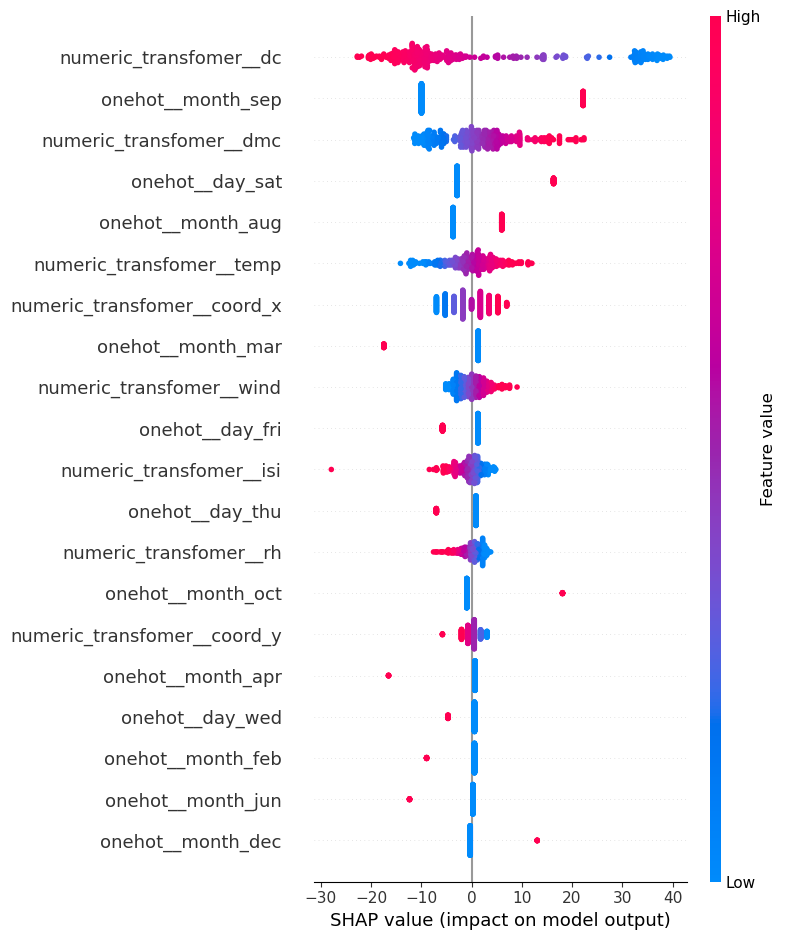

In [81]:
import shap

# Extract the preprocessed test data
data_transform_A = pipeline_A.named_steps['preprocessing'].transform(X0_train)

#Create SHAP explainer for linear model (Ridge)
explainer_A = shap.explainers.Linear(
    pipeline_A.named_steps['regressor'], 
    data_transform_A,
    feature_names=pipeline_A.named_steps['preprocessing'].get_feature_names_out()
)

# Compute SHAP values
shap_values_A = explainer_A(data_transform_A)

# Visualize
shap.summary_plot(shap_values_A, features=data_transform_A,
                  feature_names=pipeline_A.named_steps['preprocessing'].get_feature_names_out())


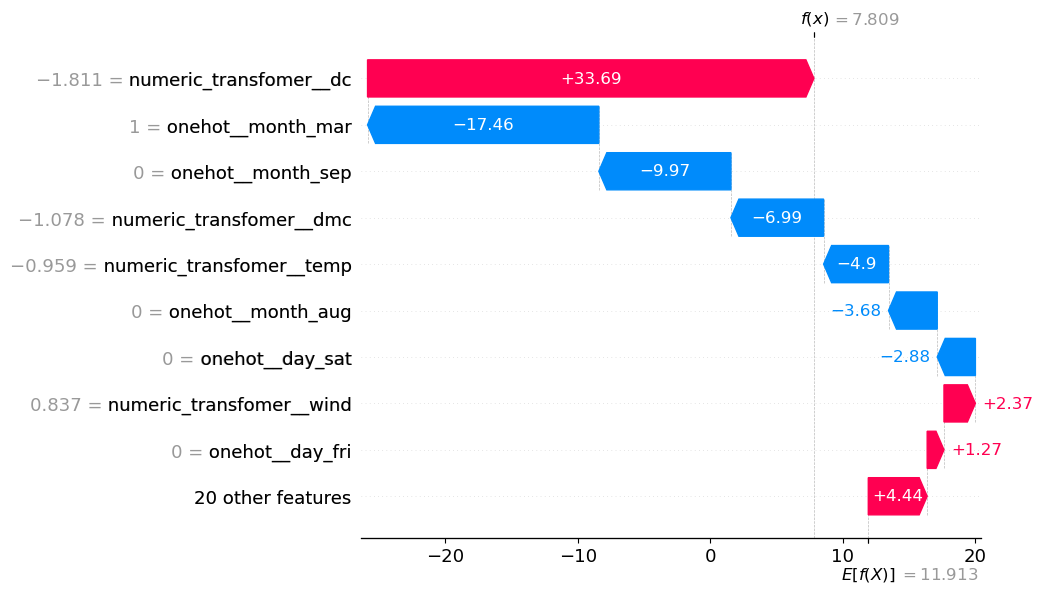

In [65]:
shap.plots.waterfall(shap_values_A[10])

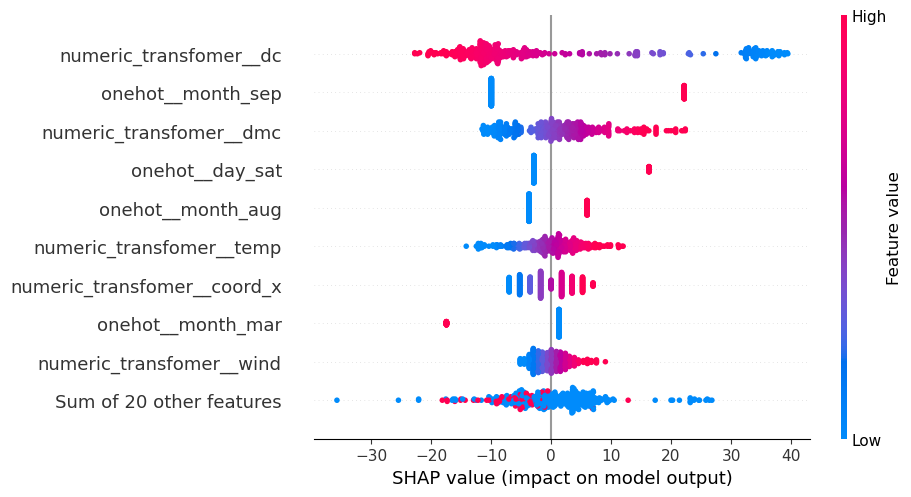

In [66]:
shap.plots.beeswarm(shap_values_A)

*(Answer here.)*

Global interpretation:
dc, dmc and temp are the variables impacting the output the most. Month of the year (Sep and Aug) and the day of the week (saturday) all also key contributors.

Local interpretation:
'dc' individually pushes the observation 34 pts higher, contributing significantly more than any other variable.

rh and isi are the least important variables and I would remove them to enhance model performance. To test this, I will redefine X by excluding them and rerunning the pipeline and will also experiment with various parameters. 

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.